# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 06 — Baseline Backtests

**Purpose:** establish formal, pre-holdout performance baselines before any walk-forward optimisation.

Notebook 05 narrowed the economically serious portfolio constructions to:

- **Hierarchical Inverse Volatility** — primary risk-aware construction;
- **Hierarchical Equal Weight** — deliberately simple challenger/benchmark.

The signal specifications carried into the baseline comparison are:

- `CORE`;
- `PT_REDUCE_25`.

`PB_ADD_25` is retained in upstream research outputs but is **not** promoted into the primary baseline set because its incremental results were generally weaker.

### Baselines tested

Notebook 06 compares SuperbCommand against three deliberately simple alternatives using the same underlying market universe:

1. **Passive long-only** — always long;
2. **12-month time-series momentum** — sign of trailing 52-week return;
3. **Dual-horizon trend** — average of 13-week and 52-week directional trend signals.

All trend signals are lagged by one week. Portfolio weights are inherited from Notebook 05 and therefore use only information available through the prior week.

### Research discipline

- Research sample ends **2025-12-31**.
- **All of 2026 remains locked final holdout.**
- No baseline parameter is optimised in this notebook.
- No winning model is selected solely from full-sample Sharpe.
- Notebook 07 remains the walk-forward research stage.


In [1]:
# ============================================================
# 6.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 06 cannot run with the holdout unlocked.")

SIGNAL_PATH = PATHS["data_processed"] / "superbcommand_weekly_signal_panel.parquet"
PORT_RETURNS_PATH = PATHS["data_processed"] / "05_portfolio_return_panel.parquet"
WEIGHTS_PATH = PATHS["data_processed"] / "05_portfolio_weights.parquet"
META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"

for p in [SIGNAL_PATH, PORT_RETURNS_PATH, WEIGHTS_PATH, META_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:
# ============================================================
# 6.2 — LOAD NOTEBOOK 05 OUTPUTS
# ============================================================
panel = pd.read_parquet(SIGNAL_PATH)
sc_returns = pd.read_parquet(PORT_RETURNS_PATH)
weights = pd.read_parquet(WEIGHTS_PATH)
meta = pd.read_csv(META_PATH, index_col=0)

try:
    panel = panel.reorder_levels(["date", "ticker"]).sort_index()
except Exception:
    panel = panel.sort_index()

for obj, name in [(panel, "signal panel"), (sc_returns, "portfolio return panel"), (weights, "weight panel")]:
    idx = obj.index.get_level_values("date") if isinstance(obj.index, pd.MultiIndex) else obj.index
    if pd.Timestamp(idx.max()) >= HOLDOUT_START:
        raise RuntimeError(f"Holdout contamination detected in {name}.")

tickers = sorted(meta.index.tolist())

PRIMARY_METHODS = ["hier_equal_weight", "hier_inverse_vol"]
PRIMARY_VARIANTS = ["CORE", "PT_REDUCE_25"]

print("Markets:", len(tickers))
print("Primary portfolio methods:", PRIMARY_METHODS)
print("Primary SuperbCommand variants:", PRIMARY_VARIANTS)


Markets: 11
Primary portfolio methods: ['hier_equal_weight', 'hier_inverse_vol']
Primary SuperbCommand variants: ['CORE', 'PT_REDUCE_25']


## 6.3 Construct underlying weekly returns

The external baselines use exactly the same market proxies as SuperbCommand. This avoids changing both the signal and the universe at the same time.


In [3]:
# ============================================================
# 6.3 — UNDERLYING WEEKLY RETURNS
# ============================================================
underlying = {}
for ticker in tickers:
    x = panel.xs(ticker, level="ticker").copy()
    underlying[ticker] = x["close"].pct_change(fill_method=None).rename(ticker)

underlying_returns = pd.concat(underlying, axis=1).sort_index()
underlying_returns = underlying_returns.loc[:RESEARCH_END]

print("Underlying return matrix:", underlying_returns.shape)
display(underlying_returns.tail())


Underlying return matrix: (1095, 11)


,BTC-USD,DBC,EEM,EFA,GLD,IEF,SHY,SPY,TIP,TLT,UUP
date,,,,,,,,,,,
2025-11-28,0.068498,0.023524,0.022976,0.027415,0.036364,0.003189,0.000602,0.036963,0.002162,0.007933,-0.006340
2025-12-05,-0.016845,0.011709,0.007732,0.006513,-0.003712,-0.007633,-0.000737,0.003366,-0.004399,-0.019124,-0.004608
2025-12-12,0.009874,-0.017574,-0.009134,0.007202,0.023290,-0.002902,0.001208,-0.005731,-0.001992,-0.009414,-0.004630
2025-12-19,-0.024006,-0.003054,0.004586,0.007148,0.009053,0.003766,0.001749,0.001234,0.000465,0.006306,0.004293
2025-12-26,-0.009102,0.026871,0.020104,0.011628,0.044409,0.002078,0.000363,0.014282,0.001001,0.002170,-0.006374


## 6.4 Fixed benchmark signals

These are **reference models**, not tuned competitors.

### Passive long
\[
s_{i,t}=1
\]

### 52-week time-series momentum
\[
s_{i,t} =
\begin{cases}
1,& P_{t-1}/P_{t-53}-1>0\\
0,& \text{otherwise}
\end{cases}
\]

### Dual-horizon trend
A market receives 0, 0.5 or 1.0 exposure according to the fraction of its lagged 13-week and 52-week trailing returns that are positive.

The baseline family is intentionally **long/cash**, matching the primary SuperbCommand architecture rather than introducing shorting that Notebook 04B did not support as a general extension.


In [4]:
# ============================================================
# 6.4 — BUILD FIXED BASELINE SIGNALS
# ============================================================
close = pd.concat(
    {t: panel.xs(t, level="ticker")["close"] for t in tickers},
    axis=1
).sort_index()

# Every decision below is made from information known by t-1.
ret_13 = close.pct_change(13, fill_method=None).shift(1)
ret_52 = close.pct_change(52, fill_method=None).shift(1)

baseline_signals = {
    "PASSIVE_LONG": pd.DataFrame(1.0, index=close.index, columns=close.columns),
    "TSMOM_52W": (ret_52 > 0).astype(float),
    "DUAL_TREND_13_52": (
        (ret_13 > 0).astype(float) + (ret_52 > 0).astype(float)
    ) / 2.0,
}

# Do not treat unavailable lookback history as a negative signal.
baseline_signals["TSMOM_52W"] = baseline_signals["TSMOM_52W"].where(ret_52.notna())
baseline_signals["DUAL_TREND_13_52"] = baseline_signals["DUAL_TREND_13_52"].where(
    ret_13.notna() & ret_52.notna()
)

for k, s in baseline_signals.items():
    print(k, s.shape, "first valid:", s.dropna(how="all").index.min())


PASSIVE_LONG (1095, 11) first valid: 2005-01-07 00:00:00
TSMOM_52W (1095, 11) first valid: 2006-01-13 00:00:00
DUAL_TREND_13_52 (1095, 11) first valid: 2006-01-13 00:00:00


## 6.5 Apply Notebook 05 portfolio weights

The weighting model is held fixed while the timing rule changes. Baseline returns therefore answer a clean question:

> Does SuperbCommand add value relative to simple passive and trend rules when portfolio construction is held constant?


In [5]:
# ============================================================
# 6.5 — BASELINE PORTFOLIO RETURNS
# ============================================================
def get_weight_matrix(method):
    if isinstance(weights.columns, pd.MultiIndex):
        W = weights.xs(method, axis=1, level="portfolio_method").copy()
    else:
        raise ValueError("Expected MultiIndex columns in Notebook 05 weight panel.")
    return W.reindex(columns=tickers)

baseline_returns = {}

for method in PRIMARY_METHODS:
    W = get_weight_matrix(method)
    common = W.index.intersection(underlying_returns.index)

    for name, signal in baseline_signals.items():
        S = signal.reindex(index=common, columns=tickers)
        R = underlying_returns.reindex(index=common, columns=tickers)
        WW = W.reindex(index=common, columns=tickers)

        # Preserve the Notebook 05 capital allocation. A zero signal becomes cash;
        # active positions are not renormalised back to 100%.
        gross = (WW * S * R).sum(axis=1, min_count=1)
        baseline_returns[(name, method)] = gross.rename((name, method))

baseline_return_panel = pd.concat(baseline_returns, axis=1)
baseline_return_panel.columns = pd.MultiIndex.from_tuples(
    baseline_return_panel.columns, names=["strategy", "portfolio_method"]
)

print("Baseline return panel:", baseline_return_panel.shape)
display(baseline_return_panel.tail())


Baseline return panel: (1095, 6)


strategy,PASSIVE_LONG,TSMOM_52W,DUAL_TREND_13_52,PASSIVE_LONG,TSMOM_52W,DUAL_TREND_13_52
portfolio_method,hier_equal_weight,hier_equal_weight,hier_equal_weight,hier_inverse_vol,hier_inverse_vol,hier_inverse_vol
date,,,,,,
2025-11-28,0.024938,0.012507,0.010959,0.008463,0.008418,0.006927
2025-12-05,-0.003912,0.000379,-0.000082,-0.002017,-0.000097,-0.000803
2025-12-12,0.000455,-0.000124,-0.000772,-0.001739,-0.000432,-0.001138
2025-12-19,-0.001864,0.002079,0.002339,0.002079,0.001621,0.002110
2025-12-26,0.007381,0.010476,0.009759,0.005026,0.007089,0.006115


## 6.6 Performance statistics


In [6]:
# ============================================================
# 6.6 — METRIC FUNCTIONS
# ============================================================
WEEKS_PER_YEAR = 52

def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    eq = (1 + r).cumprod()
    dd = eq / eq.cummax() - 1
    return dd.min()

def perf_stats(r):
    r = pd.Series(r).dropna()
    if len(r) < 2:
        return {k: np.nan for k in [
            "weeks","cagr","ann_vol","sharpe","sortino","max_drawdown",
            "calmar","best_week","worst_week","positive_week_rate"
        ]}

    years = len(r) / WEEKS_PER_YEAR
    growth = (1 + r).prod()
    cagr = growth ** (1 / years) - 1 if growth > 0 else np.nan
    ann_vol = r.std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sharpe = (r.mean() * WEEKS_PER_YEAR) / ann_vol if ann_vol > 0 else np.nan

    downside = r[r < 0].std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    sortino = (r.mean() * WEEKS_PER_YEAR) / downside if downside > 0 else np.nan

    mdd = max_drawdown(r)
    calmar = cagr / abs(mdd) if pd.notna(mdd) and mdd < 0 else np.nan

    return {
        "weeks": len(r),
        "cagr": cagr,
        "ann_vol": ann_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": mdd,
        "calmar": calmar,
        "best_week": r.max(),
        "worst_week": r.min(),
        "positive_week_rate": (r > 0).mean(),
    }


In [7]:
# ============================================================
# 6.7 — COMBINE SUPERBCOMMAND AND BASELINES
# ============================================================
all_returns = {}

for variant in PRIMARY_VARIANTS:
    for method in PRIMARY_METHODS:
        all_returns[(f"SUPERBCOMMAND_{variant}", method)] = (
            sc_returns[(variant, method)].rename((f"SUPERBCOMMAND_{variant}", method))
        )

for key, series in baseline_returns.items():
    all_returns[key] = series

comparison_panel = pd.concat(all_returns, axis=1)
comparison_panel.columns = pd.MultiIndex.from_tuples(
    comparison_panel.columns, names=["strategy", "portfolio_method"]
)

rows = []
for (strategy, method), r in all_returns.items():
    row = {"strategy": strategy, "portfolio_method": method}
    row.update(perf_stats(r))
    rows.append(row)

performance = pd.DataFrame(rows).sort_values(
    ["portfolio_method", "sharpe"], ascending=[True, False]
).reset_index(drop=True)

display(performance)


,strategy,portfolio_method,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,DUAL_TREND_13_52,hier_equal_weight,1042,0.108836,0.096206,1.122642,1.557134,-0.164009,0.663601,0.100186,-0.098051,0.576775
1,PASSIVE_LONG,hier_equal_weight,1094,0.131659,0.118742,1.102092,1.495796,-0.268229,0.490846,0.100017,-0.116503,0.561243
2,TSMOM_52W,hier_equal_weight,1042,0.106834,0.103082,1.036854,1.430407,-0.176128,0.606570,0.097783,-0.100519,0.575816
3,SUPERBCOMMAND_PT_REDUCE_25,hier_equal_weight,1095,0.099823,0.098849,1.012590,1.348914,-0.179031,0.557576,0.097780,-0.114942,0.500457
4,SUPERBCOMMAND_CORE,hier_equal_weight,1095,0.099837,0.100298,0.999549,1.321345,-0.169638,0.588529,0.097783,-0.116503,0.499543
5,DUAL_TREND_13_52,hier_inverse_vol,1042,0.045561,0.033005,1.366982,1.891144,-0.041099,1.108570,0.024477,-0.027334,0.589251
6,PASSIVE_LONG,hier_inverse_vol,1094,0.055230,0.040279,1.355490,1.730265,-0.073076,0.755784,0.021342,-0.036573,0.594150
7,TSMOM_52W,hier_inverse_vol,1042,0.044593,0.035538,1.245885,1.720411,-0.057498,0.775554,0.022529,-0.021519,0.592131
8,SUPERBCOMMAND_PT_REDUCE_25,hier_inverse_vol,1095,0.036904,0.033563,1.096897,1.477292,-0.066441,0.555439,0.027660,-0.030534,0.515068
9,SUPERBCOMMAND_CORE,hier_inverse_vol,1095,0.037469,0.034223,1.092313,1.473897,-0.069233,0.541204,0.027660,-0.031292,0.514155


## 6.8 Fair common-sample comparison

Because a 52-week trend rule requires warm-up history, headline rankings are also recomputed on the **common period in which every compared strategy is available**. This prevents the early sample from giving one model an accidental advantage.


In [8]:
# ============================================================
# 6.8 — COMMON-SAMPLE METRICS
# ============================================================
common_sample_rows = []

for method in PRIMARY_METHODS:
    cols = [c for c in comparison_panel.columns if c[1] == method]
    sub = comparison_panel[cols].dropna(how="any")

    for strategy, _ in cols:
        r = sub[(strategy, method)]
        row = {
            "strategy": strategy,
            "portfolio_method": method,
            "common_start": sub.index.min(),
            "common_end": sub.index.max(),
        }
        row.update(perf_stats(r))
        common_sample_rows.append(row)

common_performance = pd.DataFrame(common_sample_rows).sort_values(
    ["portfolio_method", "sharpe"], ascending=[True, False]
).reset_index(drop=True)

display(common_performance)


,strategy,portfolio_method,common_start,common_end,weeks,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate
0,DUAL_TREND_13_52,hier_equal_weight,2006-01-13,2025-12-26,1042,0.108836,0.096206,1.122642,1.557134,-0.164009,0.663601,0.100186,-0.098051,0.576775
1,PASSIVE_LONG,hier_equal_weight,2006-01-13,2025-12-26,1042,0.130644,0.121056,1.075875,1.478551,-0.268229,0.487060,0.100017,-0.116503,0.571017
2,SUPERBCOMMAND_PT_REDUCE_25,hier_equal_weight,2006-01-13,2025-12-26,1042,0.105175,0.101283,1.038671,1.417009,-0.179031,0.587471,0.097780,-0.114942,0.525912
3,TSMOM_52W,hier_equal_weight,2006-01-13,2025-12-26,1042,0.106834,0.103082,1.036854,1.430407,-0.176128,0.606570,0.097783,-0.100519,0.575816
4,SUPERBCOMMAND_CORE,hier_equal_weight,2006-01-13,2025-12-26,1042,0.105190,0.102769,1.025280,1.388044,-0.169638,0.620084,0.097783,-0.116503,0.524952
5,DUAL_TREND_13_52,hier_inverse_vol,2006-01-13,2025-12-26,1042,0.045561,0.033005,1.366982,1.891144,-0.041099,1.108570,0.024477,-0.027334,0.589251
6,PASSIVE_LONG,hier_inverse_vol,2006-01-13,2025-12-26,1042,0.053670,0.040488,1.312143,1.672416,-0.073076,0.734440,0.021342,-0.036573,0.607486
7,TSMOM_52W,hier_inverse_vol,2006-01-13,2025-12-26,1042,0.044593,0.035538,1.245885,1.720411,-0.057498,0.775554,0.022529,-0.021519,0.592131
8,SUPERBCOMMAND_PT_REDUCE_25,hier_inverse_vol,2006-01-13,2025-12-26,1042,0.038854,0.034385,1.126137,1.538749,-0.066441,0.584784,0.027660,-0.030534,0.541267
9,SUPERBCOMMAND_CORE,hier_inverse_vol,2006-01-13,2025-12-26,1042,0.039449,0.035062,1.121409,1.535359,-0.069233,0.569797,0.027660,-0.031292,0.540307


## 6.9 Incremental value of SuperbCommand

The principal comparisons are made within each portfolio method:

- SuperbCommand CORE vs passive;
- SuperbCommand CORE vs 52-week trend;
- SuperbCommand CORE vs dual-horizon trend;
- `PT_REDUCE_25` vs CORE.

Positive `delta_sharpe` means the strategy named first has the higher common-sample Sharpe.


In [9]:
# ============================================================
# 6.9 — PAIRWISE DELTAS
# ============================================================
pairs = [
    ("SUPERBCOMMAND_CORE", "PASSIVE_LONG"),
    ("SUPERBCOMMAND_CORE", "TSMOM_52W"),
    ("SUPERBCOMMAND_CORE", "DUAL_TREND_13_52"),
    ("SUPERBCOMMAND_PT_REDUCE_25", "SUPERBCOMMAND_CORE"),
]

delta_rows = []

for method in PRIMARY_METHODS:
    for a, b in pairs:
        x = comparison_panel[(a, method)]
        y = comparison_panel[(b, method)]
        xy = pd.concat([x.rename("a"), y.rename("b")], axis=1).dropna()

        sa = perf_stats(xy["a"])
        sb = perf_stats(xy["b"])

        delta_rows.append({
            "portfolio_method": method,
            "comparison": f"{a} minus {b}",
            "weeks": len(xy),
            "delta_cagr": sa["cagr"] - sb["cagr"],
            "delta_sharpe": sa["sharpe"] - sb["sharpe"],
            "delta_sortino": sa["sortino"] - sb["sortino"],
            "delta_max_drawdown": sa["max_drawdown"] - sb["max_drawdown"],
            "delta_calmar": sa["calmar"] - sb["calmar"],
        })

deltas = pd.DataFrame(delta_rows)
display(deltas)


,portfolio_method,comparison,weeks,delta_cagr,delta_sharpe,delta_sortino,delta_max_drawdown,delta_calmar
0,hier_equal_weight,SUPERBCOMMAND_CORE minus PASSIVE_LONG,1094,-0.031726,-0.102078,-0.173244,0.098591,0.098247
1,hier_equal_weight,SUPERBCOMMAND_CORE minus TSMOM_52W,1042,-0.001644,-0.011573,-0.042363,0.006489,0.013514
2,hier_equal_weight,SUPERBCOMMAND_CORE minus DUAL_TREND_13_52,1042,-0.003646,-0.097362,-0.169090,-0.005630,-0.043517
3,hier_equal_weight,SUPERBCOMMAND_PT_REDUCE_25 minus SUPERBCOMMAND...,1095,-0.000014,0.013041,0.027570,-0.009392,-0.030953
4,hier_inverse_vol,SUPERBCOMMAND_CORE minus PASSIVE_LONG,1094,-0.017726,-0.262667,-0.255021,0.003843,-0.214075
5,hier_inverse_vol,SUPERBCOMMAND_CORE minus TSMOM_52W,1042,-0.005144,-0.124476,-0.185052,-0.011735,-0.205757
6,hier_inverse_vol,SUPERBCOMMAND_CORE minus DUAL_TREND_13_52,1042,-0.006113,-0.245573,-0.355785,-0.028134,-0.538772
7,hier_inverse_vol,SUPERBCOMMAND_PT_REDUCE_25 minus SUPERBCOMMAND...,1095,-0.000565,0.004584,0.003395,0.002792,0.014235


## 6.10 Rolling performance

A robust baseline should not depend on one short historical episode. Five-year rolling Sharpe is therefore shown as a descriptive stability diagnostic.

This is **not** used to optimise parameters.


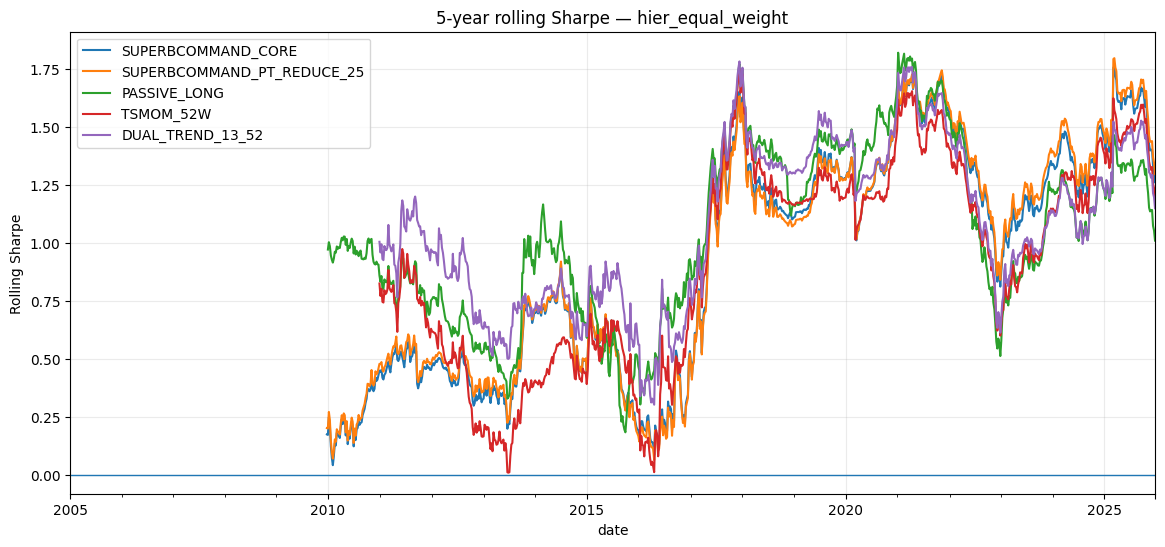

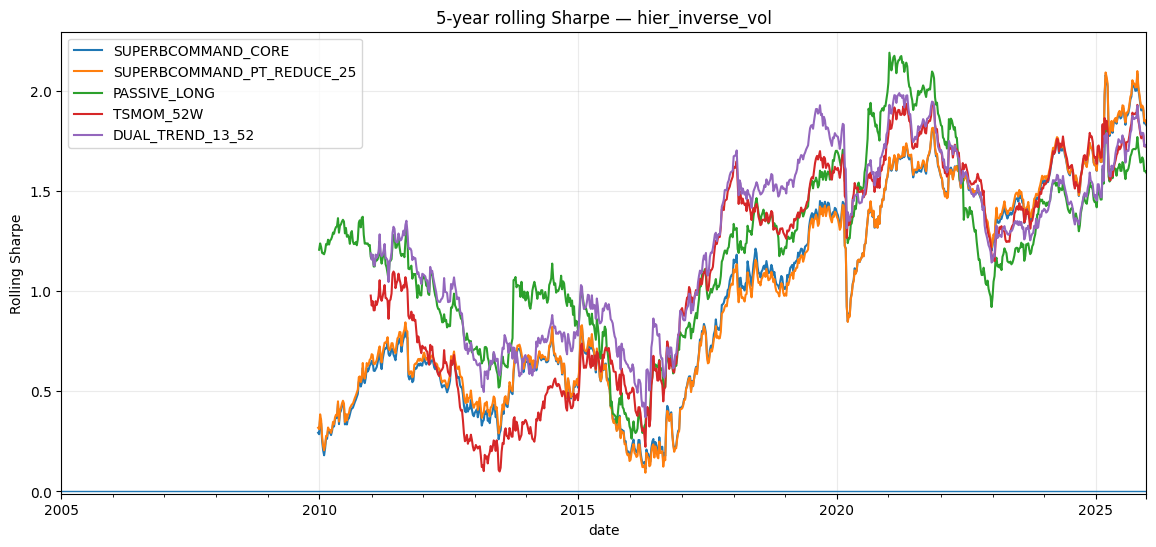

In [10]:
# ============================================================
# 6.10 — 5-YEAR ROLLING SHARPE
# ============================================================
ROLL_WEEKS = 5 * 52

def rolling_sharpe(r, window=ROLL_WEEKS):
    mean = r.rolling(window, min_periods=window).mean() * WEEKS_PER_YEAR
    vol = r.rolling(window, min_periods=window).std(ddof=1) * np.sqrt(WEEKS_PER_YEAR)
    return mean / vol.replace(0, np.nan)

for method in PRIMARY_METHODS:
    plt.figure(figsize=(14, 6))
    for strategy in [
        "SUPERBCOMMAND_CORE",
        "SUPERBCOMMAND_PT_REDUCE_25",
        "PASSIVE_LONG",
        "TSMOM_52W",
        "DUAL_TREND_13_52",
    ]:
        r = comparison_panel[(strategy, method)]
        rolling_sharpe(r).plot(label=strategy)

    plt.axhline(0, linewidth=1)
    plt.title(f"5-year rolling Sharpe — {method}")
    plt.ylabel("Rolling Sharpe")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 6.11 Equity curves


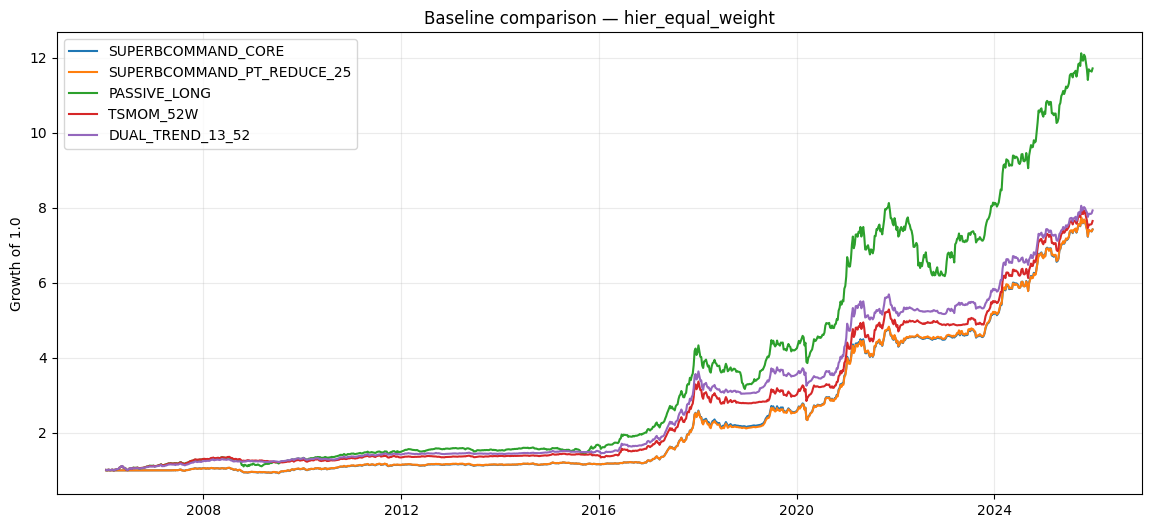

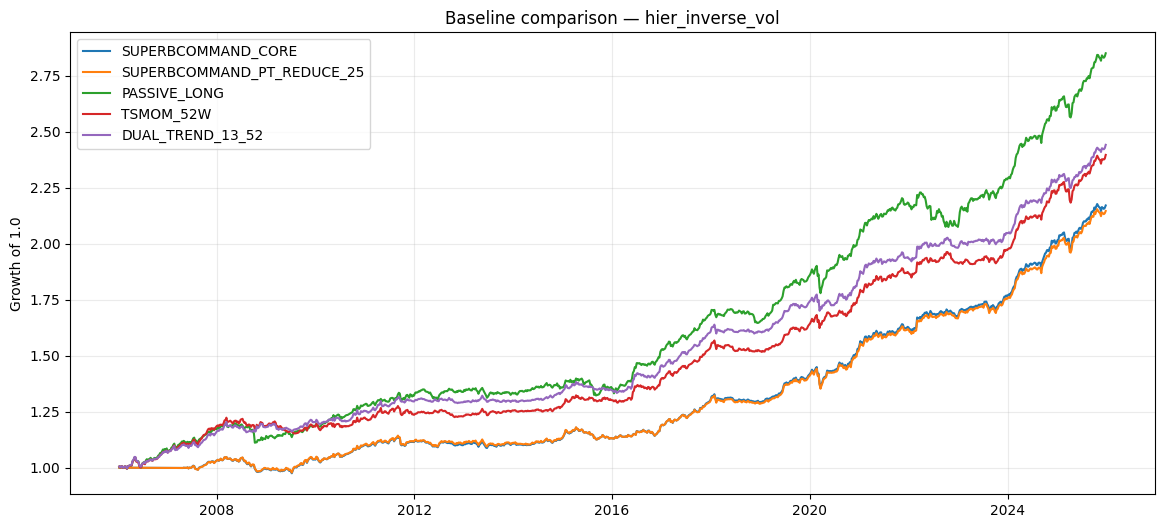

In [11]:
# ============================================================
# 6.11 — COMMON-SAMPLE EQUITY CURVES
# ============================================================
for method in PRIMARY_METHODS:
    cols = [c for c in comparison_panel.columns if c[1] == method]
    sub = comparison_panel[cols].dropna(how="any")

    plt.figure(figsize=(14, 6))
    for strategy, _ in cols:
        eq = (1 + sub[(strategy, method)]).cumprod()
        plt.plot(eq.index, eq.values, label=strategy)

    plt.title(f"Baseline comparison — {method}")
    plt.ylabel("Growth of 1.0")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 6.12 Drawdowns


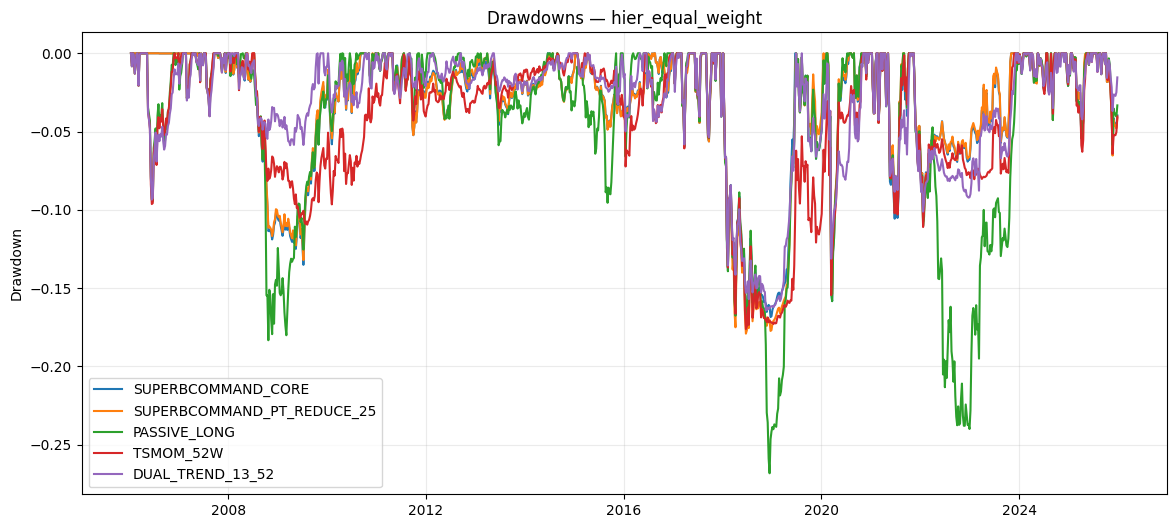

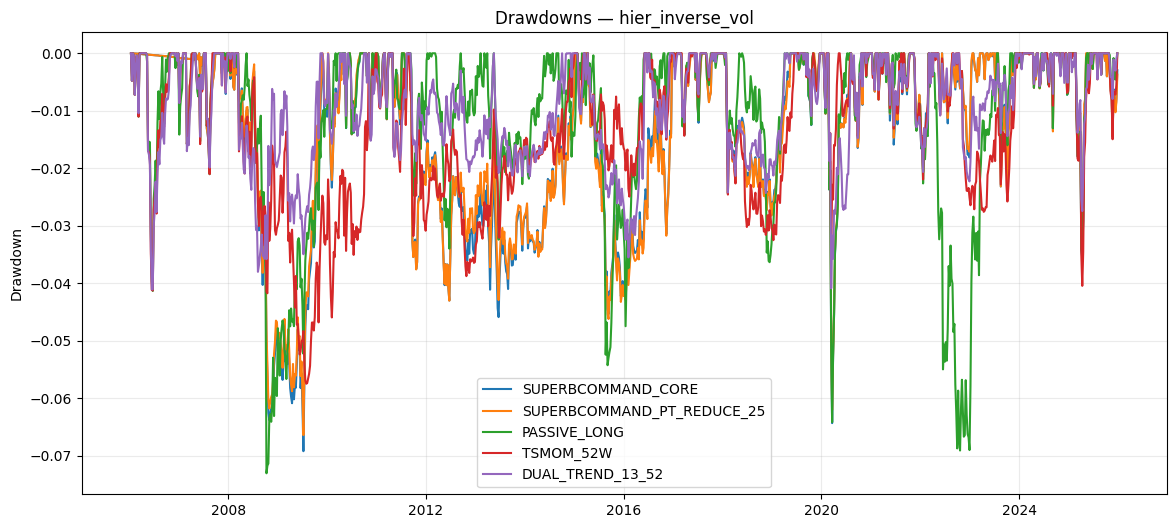

In [12]:
# ============================================================
# 6.12 — DRAWDOWN COMPARISON
# ============================================================
for method in PRIMARY_METHODS:
    cols = [c for c in comparison_panel.columns if c[1] == method]
    sub = comparison_panel[cols].dropna(how="any")

    plt.figure(figsize=(14, 6))
    for strategy, _ in cols:
        eq = (1 + sub[(strategy, method)]).cumprod()
        dd = eq / eq.cummax() - 1
        plt.plot(dd.index, dd.values, label=strategy)

    plt.title(f"Drawdowns — {method}")
    plt.ylabel("Drawdown")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()


## 6.13 Fixed stress-period comparison

These periods are inherited as descriptive historical stress tests. They are not selected or altered based on Notebook 06 performance.


In [13]:
# ============================================================
# 6.13 — STRESS PERIODS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for (strategy, method), r in all_returns.items():
        rr = r.loc[start:end].dropna()
        if len(rr) == 0:
            continue
        stress_rows.append({
            "period": period,
            "strategy": strategy,
            "portfolio_method": method,
            "weeks": len(rr),
            "total_return": (1 + rr).prod() - 1,
            "max_drawdown": max_drawdown(rr),
            "worst_week": rr.min(),
        })

stress = pd.DataFrame(stress_rows)
display(stress)


,period,strategy,portfolio_method,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,SUPERBCOMMAND_CORE,hier_equal_weight,91,-0.058381,-0.118898,-0.018737
1,Global Financial Crisis,SUPERBCOMMAND_CORE,hier_inverse_vol,91,-0.008965,-0.063843,-0.015752
2,Global Financial Crisis,SUPERBCOMMAND_PT_REDUCE_25,hier_equal_weight,91,-0.053421,-0.116756,-0.018746
3,Global Financial Crisis,SUPERBCOMMAND_PT_REDUCE_25,hier_inverse_vol,91,-0.006475,-0.061787,-0.015752
4,Global Financial Crisis,PASSIVE_LONG,hier_equal_weight,91,-0.018414,-0.183268,-0.066784
5,Global Financial Crisis,TSMOM_52W,hier_equal_weight,91,0.060589,-0.081561,-0.023569
6,Global Financial Crisis,DUAL_TREND_13_52,hier_equal_weight,91,0.061973,-0.056386,-0.022762
7,Global Financial Crisis,PASSIVE_LONG,hier_inverse_vol,91,0.028634,-0.073076,-0.036573
8,Global Financial Crisis,TSMOM_52W,hier_inverse_vol,91,0.072233,-0.041752,-0.017071
9,Global Financial Crisis,DUAL_TREND_13_52,hier_inverse_vol,91,0.070493,-0.038025,-0.016781


## 6.14 Calendar-year consistency

Annual results are diagnostic only. The 2026 holdout is absent by construction.


In [14]:
# ============================================================
# 6.14 — CALENDAR-YEAR RETURNS
# ============================================================
annual_rows = []

for (strategy, method), r in all_returns.items():
    rr = r.dropna()
    annual = (1 + rr).groupby(rr.index.year).prod() - 1
    for year, value in annual.items():
        annual_rows.append({
            "year": int(year),
            "strategy": strategy,
            "portfolio_method": method,
            "return": value,
        })

annual_returns = pd.DataFrame(annual_rows)
annual_pivot = annual_returns.pivot_table(
    index="year",
    columns=["portfolio_method", "strategy"],
    values="return"
)

display(annual_pivot.tail(10))


portfolio_method hier_equal_weight                                  \
strategy          DUAL_TREND_13_52 PASSIVE_LONG SUPERBCOMMAND_CORE   
year                                                                 
2016                      0.178763     0.248236           0.085166   
2017                      0.948436     0.971158           0.957442   
2018                     -0.123476    -0.207499          -0.130118   
2019                      0.163359     0.289119           0.191976   
2020                      0.222627     0.396359           0.384547   
2021                      0.210054     0.285456           0.267583   
2022                     -0.015716    -0.187520          -0.006839   
2023                      0.123236     0.308432           0.152079   
2024                      0.240253     0.290191           0.290191   
2025                      0.101183     0.123339           0.113219   

portfolio_method                                      hier_inverse_vol  \
strategy         SUPERBCOMMAND_PT_REDUCE_25 TSMOM_52W DUAL_TREND_13_52   
year                                                                     
2016                               0.085540  0.178243         0.081159   
2017                               0.941674  0.951754         0.103131   
2018                              -0.140350 -0.134502        -0.000355   
2019                               0.204729  0.078275         0.082412   
2020                               0.382342  0.300688         0.056102   
2021                               0.283372  0.260886         0.053750   
2022                              -0.004847 -0.009637         0.023793   
2023                               0.151145  0.121855         0.033125   
2024                               0.281290  0.282126         0.111042   
2025                               0.115419  0.088259         0.073406   

portfolio_method                                                             \
strategy         PASSIVE_LONG SUPERBCOMMAND_CORE SUPERBCOMMAND_PT_REDUCE_25   
year                                                                          
2016                 0.121889           0.050196                   0.050270   
2017                 0.105837           0.096286                   0.092286   
2018                -0.021380          -0.009754                  -0.011105   
2019                 0.123695           0.096168                   0.095703   
2020                 0.088706           0.081922                   0.079857   
2021                 0.079061           0.061890                   0.062825   
2022                -0.048257           0.030721                   0.031134   
2023                 0.102199           0.053857                   0.052646   
2024                 0.134677           0.133601                   0.127869   
2025                 0.098319           0.084387                   0.084825   

portfolio_method            
strategy         TSMOM_52W  
year                        
2016              0.072956  
2017              0.101162  
2018             -0.012177  
2019              0.077838  
2020              0.074462  
2021              0.061512  
2022              0.023925  
2023              0.030148  
2024              0.128049  
2025              0.077702

## 6.15 Baseline robustness summary

This table deliberately reports evidence rather than automatically declaring a winner.


In [15]:
# ============================================================
# 6.15 — ROBUSTNESS SUMMARY
# ============================================================
summary_rows = []

for method in PRIMARY_METHODS:
    sub = common_performance[common_performance["portfolio_method"] == method].copy()
    core = sub[sub["strategy"] == "SUPERBCOMMAND_CORE"].iloc[0]
    pt = sub[sub["strategy"] == "SUPERBCOMMAND_PT_REDUCE_25"].iloc[0]

    baseline_sub = sub[sub["strategy"].isin(["PASSIVE_LONG", "TSMOM_52W", "DUAL_TREND_13_52"])]
    best_baseline = baseline_sub.sort_values("sharpe", ascending=False).iloc[0]

    summary_rows.append({
        "portfolio_method": method,
        "core_sharpe": core["sharpe"],
        "pt_reduce_sharpe": pt["sharpe"],
        "best_baseline": best_baseline["strategy"],
        "best_baseline_sharpe": best_baseline["sharpe"],
        "core_minus_best_baseline_sharpe": core["sharpe"] - best_baseline["sharpe"],
        "pt_minus_core_sharpe": pt["sharpe"] - core["sharpe"],
        "core_max_drawdown": core["max_drawdown"],
        "pt_max_drawdown": pt["max_drawdown"],
    })

robustness_summary = pd.DataFrame(summary_rows)
display(robustness_summary)


,portfolio_method,core_sharpe,pt_reduce_sharpe,best_baseline,best_baseline_sharpe,core_minus_best_baseline_sharpe,pt_minus_core_sharpe,core_max_drawdown,pt_max_drawdown
0,hier_equal_weight,1.025280,1.038671,DUAL_TREND_13_52,1.122642,-0.097362,0.013390,-0.169638,-0.179031
1,hier_inverse_vol,1.121409,1.126137,DUAL_TREND_13_52,1.366982,-0.245573,0.004728,-0.069233,-0.066441


## 6.16 Save outputs


In [16]:
# ============================================================
# 6.16 — SAVE OUTPUTS
# ============================================================
PERF_PATH = PATHS["results"] / "06_baseline_performance.csv"
COMMON_PERF_PATH = PATHS["results"] / "06_baseline_common_sample_performance.csv"
DELTA_PATH = PATHS["results"] / "06_baseline_pairwise_deltas.csv"
STRESS_PATH = PATHS["results"] / "06_baseline_stress_summary.csv"
ANNUAL_PATH = PATHS["results"] / "06_baseline_annual_returns.csv"
ROBUSTNESS_PATH = PATHS["results"] / "06_baseline_robustness_summary.csv"
BASELINE_RETURNS_PATH = PATHS["data_processed"] / "06_baseline_return_panel.parquet"
COMPARISON_RETURNS_PATH = PATHS["data_processed"] / "06_full_baseline_comparison_panel.parquet"

performance.to_csv(PERF_PATH, index=False)
common_performance.to_csv(COMMON_PERF_PATH, index=False)
deltas.to_csv(DELTA_PATH, index=False)
stress.to_csv(STRESS_PATH, index=False)
annual_returns.to_csv(ANNUAL_PATH, index=False)
robustness_summary.to_csv(ROBUSTNESS_PATH, index=False)
baseline_return_panel.to_parquet(BASELINE_RETURNS_PATH)
comparison_panel.to_parquet(COMPARISON_RETURNS_PATH)

print("Saved Notebook 06 outputs.")


Saved Notebook 06 outputs.


## 6.17 Validation suite


In [17]:
# ============================================================
# 6.17 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = comparison_panel.index.max() <= RESEARCH_END
checks["2026_absent"] = not (comparison_panel.index.year == 2026).any()

expected_strategies = {
    "SUPERBCOMMAND_CORE",
    "SUPERBCOMMAND_PT_REDUCE_25",
    "PASSIVE_LONG",
    "TSMOM_52W",
    "DUAL_TREND_13_52",
}
checks["all_baselines_present"] = set(performance["strategy"]) == expected_strategies
checks["primary_methods_present"] = set(performance["portfolio_method"]) == set(PRIMARY_METHODS)

# Explicit one-week information lag tests for trend signals.
test_52 = (close.pct_change(52, fill_method=None).shift(1) > 0).astype(float)
test_52 = test_52.where(close.pct_change(52, fill_method=None).shift(1).notna())
checks["tsmom_one_week_lag_enforced"] = baseline_signals["TSMOM_52W"].equals(test_52)

checks["no_short_exposure_in_baselines"] = all(
    (s.dropna() >= 0).all().all() for s in baseline_signals.values()
)

checks["common_sample_exists"] = len(common_performance) == len(expected_strategies) * len(PRIMARY_METHODS)

checks["output_files_written"] = all(p.exists() for p in [
    PERF_PATH, COMMON_PERF_PATH, DELTA_PATH, STRESS_PATH,
    ANNUAL_PATH, ROBUSTNESS_PATH, BASELINE_RETURNS_PATH,
    COMPARISON_RETURNS_PATH
])

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 06 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 06 STATUS: PASS")
print("=" * 78)
print("Formal baseline backtests completed.")
print("No baseline hyperparameters were optimised.")
print("No final strategy or portfolio method has been selected.")
print("2026 holdout: NOT ACCESSED")
print("Proceed next to Notebook 07 — Walk-Forward Research.")


                         check  passed
                holdout_absent    True
                   2026_absent    True
         all_baselines_present    True
       primary_methods_present    True
   tsmom_one_week_lag_enforced    True
no_short_exposure_in_baselines    True
          common_sample_exists    True
          output_files_written    True

NOTEBOOK 06 STATUS: PASS
Formal baseline backtests completed.
No baseline hyperparameters were optimised.
No final strategy or portfolio method has been selected.
2026 holdout: NOT ACCESSED
Proceed next to Notebook 07 — Walk-Forward Research.


In [18]:
# ============================================================
# 6.18 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "06",
    "notebook_name": "Baseline Backtests",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_accessed": False,
    "primary_superbcommand_variants": PRIMARY_VARIANTS,
    "primary_portfolio_methods": PRIMARY_METHODS,
    "baseline_strategies": list(baseline_signals.keys()),
    "baseline_parameters": {
        "tsmom_lookback_weeks": 52,
        "dual_trend_lookbacks_weeks": [13, 52],
        "shorting": False,
        "signal_lag_weeks": 1,
        "renormalise_after_signal": False,
    },
    "outputs": {
        "performance": str(PERF_PATH),
        "common_sample_performance": str(COMMON_PERF_PATH),
        "pairwise_deltas": str(DELTA_PATH),
        "stress_summary": str(STRESS_PATH),
        "annual_returns": str(ANNUAL_PATH),
        "robustness_summary": str(ROBUSTNESS_PATH),
        "baseline_return_panel": str(BASELINE_RETURNS_PATH),
        "comparison_return_panel": str(COMPARISON_RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "06_baseline_backtests_manifest.json"
with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/06_baseline_backtests_manifest.json


---

# End of Notebook 06

Notebook 06 establishes the formal pre-holdout baseline comparison.

It does **not** select the final model and does **not** access 2026.

## Next notebook

**Notebook 07 — Walk-Forward Research**
